In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure inline plotting styles for high-fidelity rendering
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})
print("🔬 Setup complete. Analytical environment initialized.")

🔬 Setup complete. Analytical environment initialized.


In [2]:
# Create workspace directories
os.makedirs("inspection_dataset/images", exist_ok=True)
os.makedirs("inspection_plots", exist_ok=True)

np.random.seed(42)
n_samples = 250
defect_types = ['Surface Crack', 'Surface Scratch', 'Missing Component', 'Blister', 'Contamination']
defect_probs = [0.25, 0.35, 0.15, 0.10, 0.15]

records = []
for i in range(n_samples):
    prod_id = f"PROD_{1000+i}"
    dtype = np.random.choice(defect_types, p=defect_probs)
    
    # 1. Size Score (30% weight)
    size_score = np.random.randint(15, 100)
    # 2. Location Score (25% weight)
    loc_score = np.random.randint(10, 100)
    # 3. Defect Type Score (25% weight)
    type_base = {'Surface Scratch': 30, 'Blister': 55, 'Contamination': 65, 'Surface Crack': 85, 'Missing Component': 95}
    type_score = np.clip(type_base[dtype] + np.random.randint(-10, 10), 10, 100)
    # 4. Confidence Score (20% weight)
    conf_score = np.random.randint(60, 100)
    
    # Mathematical execution from VisionInspect AI Framework
    sev_score = round((size_score * 0.30) + (loc_score * 0.25) + (type_score * 0.25) + (conf_score * 0.20), 1)
    
    # Map out operational actions based on severity boundaries
    if sev_score >= 80: level, action = 'Critical', 'Reject Product & Trigger Quality Inspection Workflow'
    elif sev_score >= 60: level, action = 'High', 'Repair / Rework Recommended'
    elif sev_score >= 40: level, action = 'Medium', 'Inspection Review Required'
    else: level, action = 'Low', 'Product Acceptable'
        
    img_filename = f"{prod_id}.png"
    records.append([prod_id, dtype, size_score, loc_score, type_score, conf_score, sev_score, level, action, img_filename])
    
    # Generate an artificial gray matrix to represent an industrial component
    img = np.full((300, 300, 3), 200, dtype=np.uint8)
    radius = int(np.clip(size_score // 4, 5, 50))
    cv2.circle(img, (150, 150), radius, (60, 60, 60), -1) # Center defect anomaly
    cv2.putText(img, dtype, (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    cv2.imwrite(f"inspection_dataset/images/{img_filename}", img)
    
cols = ['Product_ID', 'Defect_Type', 'Size_Score', 'Location_Score', 'Type_Score', 'Confidence_Score', 'Severity_Score', 'Severity_Level', 'Recommended_Action', 'Image_Path']
df = pd.DataFrame(records, columns=cols)
df.to_csv("inspection_dataset/metadata.csv", index=False)

print(f"✅ Generated {n_samples} structured inspection records.")
df.head()

✅ Generated 250 structured inspection records.


,Product_ID,Defect_Type,Size_Score,Location_Score,Type_Score,Confidence_Score,Severity_Score,Severity_Level,Recommended_Action,Image_Path
0,PROD_1000,Surface Scratch,29,81,26,78,51.1,Medium,Inspection Review Required,PROD_1000.png
1,PROD_1001,Surface Crack,89,97,78,99,90.2,Critical,Reject Product & Trigger Quality Inspection Wo...,PROD_1001.png
2,PROD_1002,Missing Component,36,62,86,83,64.4,High,Repair / Rework Recommended,PROD_1002.png
3,PROD_1003,Blister,52,11,45,71,43.8,Medium,Inspection Review Required,PROD_1003.png
4,PROD_1004,Missing Component,63,68,94,87,76.8,High,Repair / Rework Recommended,PROD_1004.png


C:\Users\KANNA\AppData\Local\Temp\ipykernel_25504\973616039.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Severity_Level', order=order, palette=colors, ax=axes[0,0])
C:\Users\KANNA\AppData\Local\Temp\ipykernel_25504\973616039.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Defect_Type', y='Severity_Score', palette="Set2", ax=axes[0,1])


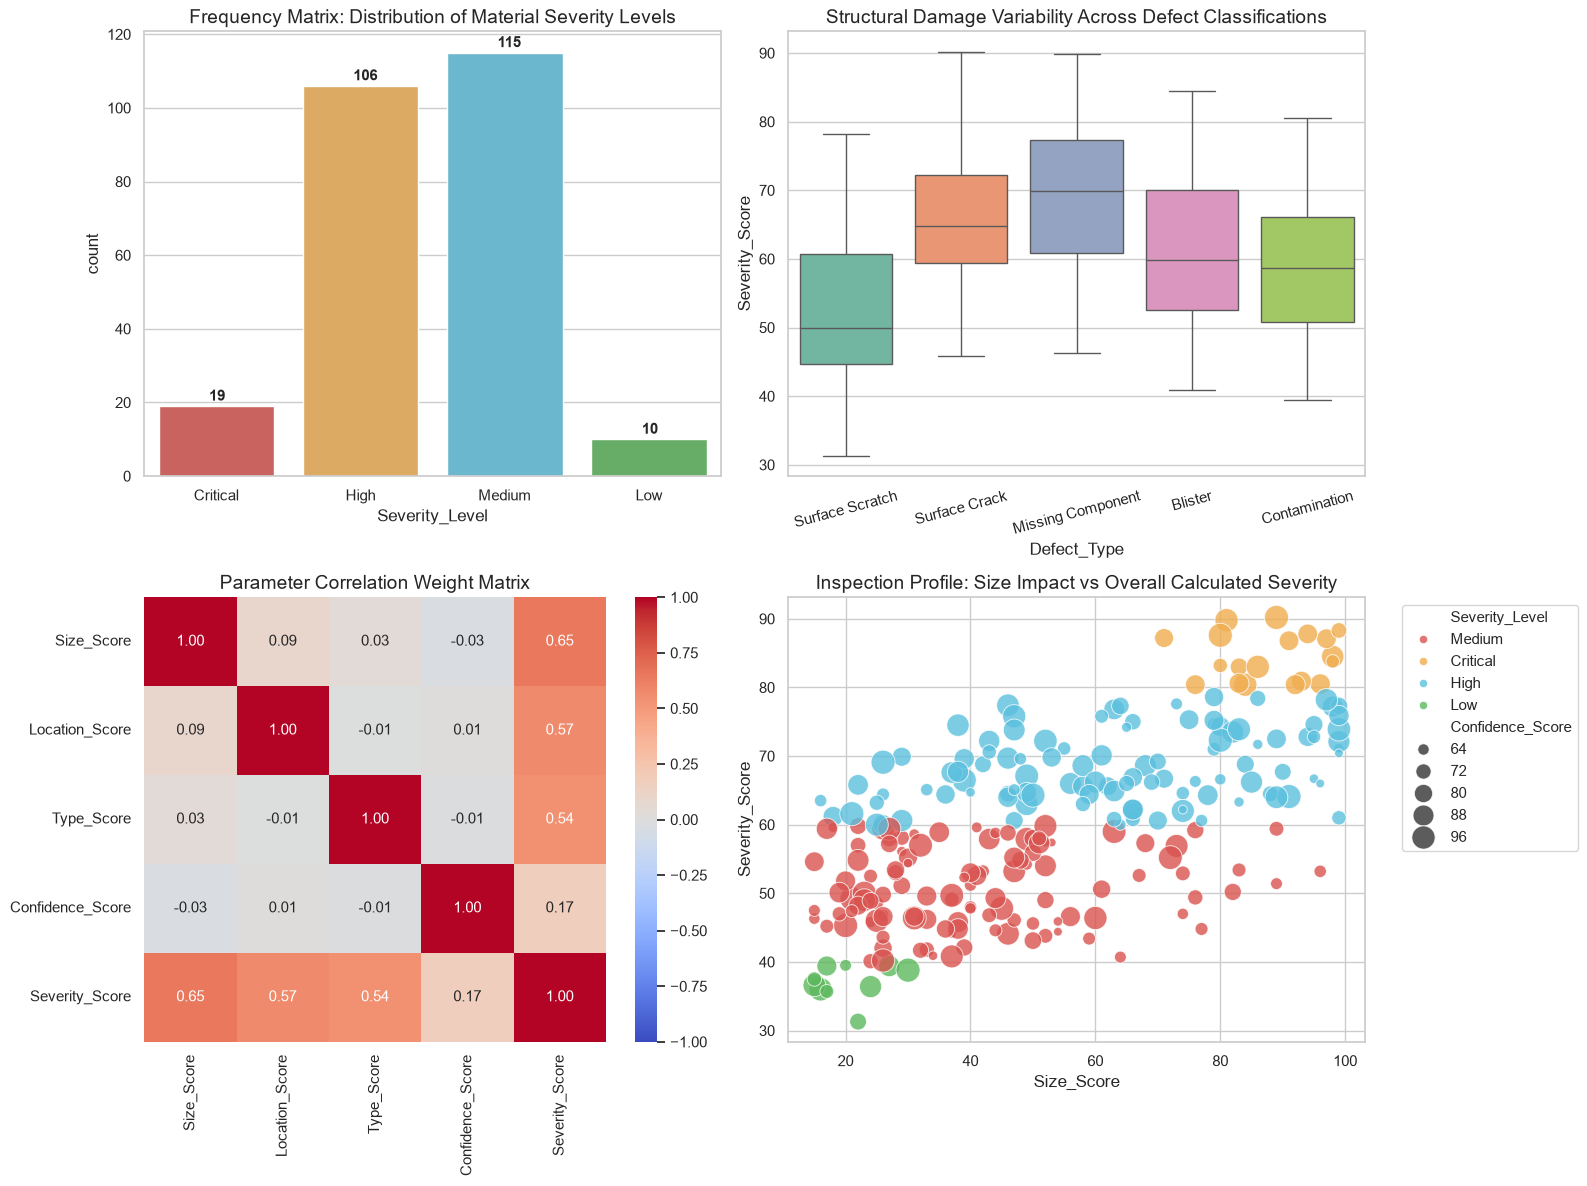

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
order = ['Critical', 'High', 'Medium', 'Low']
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']

# 1. Severity Distribution
sns.countplot(data=df, x='Severity_Level', order=order, palette=colors, ax=axes[0,0])
axes[0,0].set_title("Frequency Matrix: Distribution of Material Severity Levels")
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}', (p.get_x()+0.35, p.get_height()+1.5), fontweight='bold')

# 2. Defect Type Severity Ranges
sns.boxplot(data=df, x='Defect_Type', y='Severity_Score', palette="Set2", ax=axes[0,1])
axes[0,1].set_title("Structural Damage Variability Across Defect Classifications")
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Correlation Map
metrics = ['Size_Score', 'Location_Score', 'Type_Score', 'Confidence_Score', 'Severity_Score']
sns.heatmap(df[metrics].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, ax=axes[1,0])
axes[1,0].set_title("Parameter Correlation Weight Matrix")

# 4. Multi-dimensional Profile Scatter Plot
sns.scatterplot(data=df, x='Size_Score', y='Severity_Score', hue='Severity_Level', size='Confidence_Score', sizes=(40, 300), palette=colors, alpha=0.8, ax=axes[1,1])
axes[1,1].set_title("Inspection Profile: Size Impact vs Overall Calculated Severity")
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("inspection_plots/dashboard_summary.png", dpi=150)
plt.show()

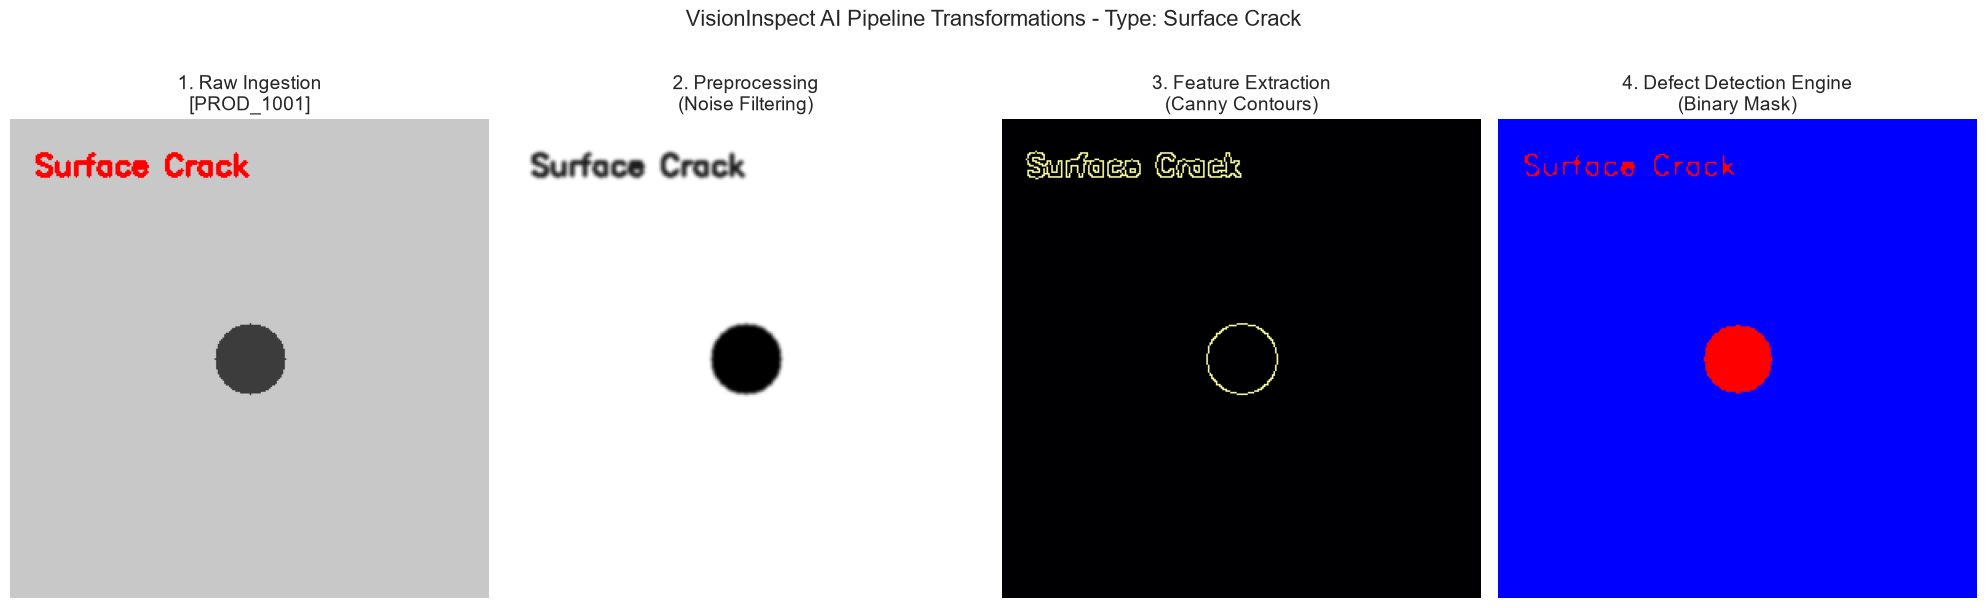

In [4]:
# Grab a sample that flagged a critical threat level
critical_samples = df[df['Severity_Level'] == 'Critical']
sample_row = critical_samples.iloc[0] if not critical_samples.empty else df.iloc[0]
img_path = f"inspection_dataset/images/{sample_row['Image_Path']}"

# Read image via OpenCV and map steps
src = cv2.imread(img_path)
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
_, thresholded = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY_INV)

# Construct inline inspection view
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"1. Raw Ingestion\n[{sample_row['Product_ID']}]")
axes[0].axis('off')

axes[1].imshow(blurred, cmap='gray')
axes[1].set_title("2. Preprocessing\n(Noise Filtering)")
axes[1].axis('off')

axes[2].imshow(edges, cmap='inferno')
axes[2].set_title("3. Feature Extraction\n(Canny Contours)")
axes[2].axis('off')

axes[3].imshow(thresholded, cmap='bwr')
axes[3].set_title("4. Defect Detection Engine\n(Binary Mask)")
axes[3].axis('off')

plt.suptitle(f"VisionInspect AI Pipeline Transformations - Type: {sample_row['Defect_Type']}", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [7]:
total_inspected = len(df)
counts = df['Severity_Level'].value_counts()
automation_pass_rate = round(((counts.get('Low', 0) + counts.get('Medium', 0)) / total_inspected) * 100, 2)

report_content = f"""# VisionInspect AI - Production Quality Analytics Summary Report
Generated automated audit logging output from system runs.

## 📊 1. Macro Production Summary KPIs
* **Total Manufacturing Volume Processed**: {total_inspected} items
* **Automated Product Acceptance Rate**: {automation_pass_rate}% (Low + Medium Severity items)
* **Average Computer Vision Model Inference Confidence**: {df['Confidence_Score'].mean().round(2)}%
* **Critical Component Halt Count (Immediate Rejections)**: {counts.get('Critical', 0)}

---

## 📈 2. Volumetric Breakdown of Component Status
| Severity Level | Threshold Limits | Captured Count | Operational Directive Required |
| :--- | :--- | :---: | :--- |
| 🔴 **Critical** | Score 80 - 100 | {counts.get('Critical', 0)} | Reject Product & Trigger Quality Inspection Workflow |
| 🟠 **High** | Score 60 - 79 | {counts.get('High', 0)} | Repair / Rework Recommended |
| 🟡 **Medium** | Score 40 - 59 | {counts.get('Medium', 0)} | Inspection Review Required |
| 🟢 **Low** | Score 0 - 39 | {counts.get('Low', 0)} | Product Acceptable |

---

## 🔬 3. Granular Quality Failures by Defect Classification
{df.groupby('Defect_Type')[['Size_Score', 'Location_Score', 'Confidence_Score', 'Severity_Score']].mean().round(2).to_markdown()}
"""

with open("Inspection_Executive_Report.md", "w", encoding="utf-8") as f:
    f.write(report_content)
print("📝 Complete executive text report generated and saved to drive as 'Inspection_Executive_Report.md'!")

📝 Complete executive text report generated and saved to drive as 'Inspection_Executive_Report.md'!


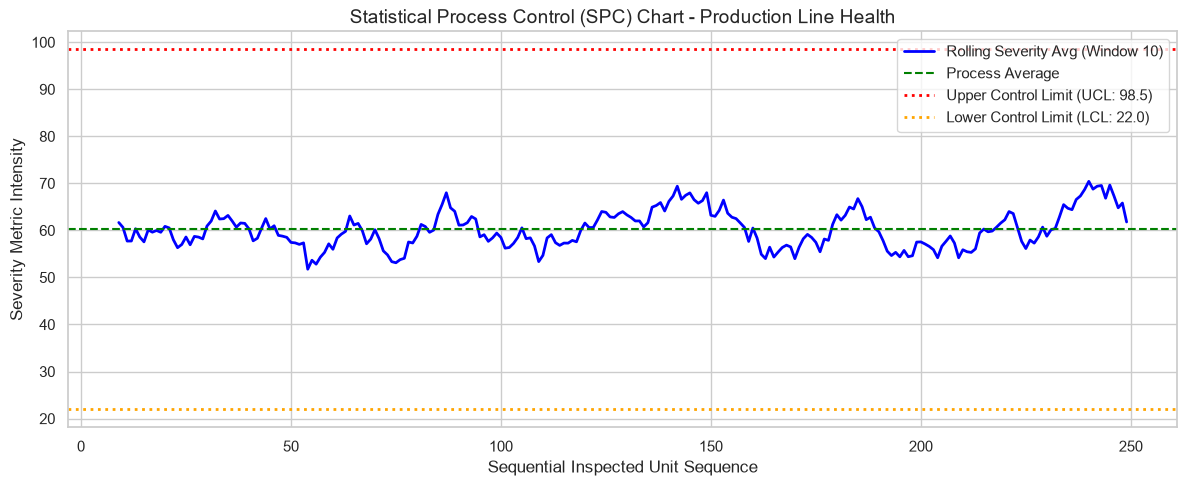

In [8]:
# Create a rolling window analysis cell in your notebook
df_sorted = df.copy().reset_index()

# Calculate a 10-product rolling average of the Severity Score
df_sorted['Rolling_Mean'] = df_sorted['Severity_Score'].rolling(window=10).mean()
global_mean = df_sorted['Severity_Score'].mean()
global_std = df_sorted['Severity_Score'].std()

# Define 3-Sigma Control Limits
ucl = global_mean + (3 * global_std)
lcl = max(0, global_mean - (3 * global_std))

plt.figure(figsize=(12, 5))
plt.plot(df_sorted['Rolling_Mean'], label='Rolling Severity Avg (Window 10)', color='blue', linewidth=2)
plt.axhline(global_mean, color='green', linestyle='--', label='Process Average')
plt.axhline(ucl, color='red', linestyle=':', linewidth=2, label=f'Upper Control Limit (UCL: {ucl:.1f})')
plt.axhline(lcl, color='orange', linestyle=':', linewidth=2, label=f'Lower Control Limit (LCL: {lcl:.1f})')

plt.title("Statistical Process Control (SPC) Chart - Production Line Health")
plt.xlabel("Sequential Inspected Unit Sequence")
plt.ylabel("Severity Metric Intensity")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()